## Gemini Pro SVG Generation



## Setup



In [1]:
import pandas as pd
import ast
from tqdm.notebook import tqdm
tqdm.pandas()

from llm_tool import call_llm



## Load Data



In [2]:
df = pd.read_csv("test_set.csv")
# df = df.sample(n=10, random_state=33).reset_index(drop=True)
# df_parsed = df.copy()
# df['multiple_choice_qa'] = df_parsed['multiple_choice_qa'].apply(ast.literal_eval)
df



,id,description
0,02d892,a purple forest at dusk
1,0dcd2e,gray wool coat with a faux fur collar
2,1e9ac1,a lighthouse overlooking the ocean
3,2b25db,burgundy corduroy pants with patch pockets and...
4,4e6a54,orange corduroy overalls
5,4f1b00,a purple silk scarf with tassel trim
6,61b500,a green lagoon under a cloudy sky
7,65cc74,crimson rectangles forming a chaotic grid
8,7c4414,purple pyramids spiraling around a bronze cone
9,996c3a,magenta trapezoids layered on a transluscent s...


## Initialize Gemini Pro Model



In [3]:
# Define which model to use
# Options: 'gpt-5', 'claude-opus', 'gemini-pro', 'gemini-flash', 'deepseek-v3', etc.
model_name = "gemini-pro"

# Define the system prompt for SVG generation
system_prompt = """You are an expert SVG code generator. Generate ONLY valid SVG code with NO explanations, NO markdown, NO text before or after.

CRITICAL RULES:
1. Your response MUST start with: <svg width="384" height="384"
2. Your response MUST end with: </svg>
3. Do NOT include: markdown code blocks, explanations, comments, or any text outside the SVG tags
4. SVG viewBox MUST be: viewBox="0 0 384 384"
5. NO text, letters, or numbers inside the image

Your ENTIRE response must be valid SVG code that starts with <svg and ends with </svg>."""

print(f"Using model: {model_name}")
print("System prompt configured for SVG generation")



Using model: gemini-pro
System prompt configured for SVG generation


## Helper Function



In [4]:
import re

def generate_svg(description: str) -> str:
    """Generate SVG code from description using LLM"""
    # Use the same prompt format as SD generation
    # prompt_prefix = "a stylized digital painting presenting a"
    # prompt_suffix = (
    #     ". The painting promote vector-art aesthetic, "
    #     "in watercolor art style with vibrant and clean background. "
    #     "The overall atmosphere is tranquil yet powerful, raw-photo "
    #     "hyper-detail, 4K, cinematic lighting, award-winning, masterpiece."
    # )
    
    # user_prompt = f"{prompt_prefix} {description}{prompt_suffix}\n\nIMPORTANT: Return valid SVG code. Start your response immediately with <svg and end with </svg>. Do not include any other text."
    
    user_prompt = f'Generate a clean and beautiful SVG illustration of: {description}. Start your response immediately with <svg and end with </svg>. Do not include any other text.'

    # OCR injection to prevent hallucination (same as SD generation)
    injection = '<path d="M20 364 L24 356 L28 364 M22 360 L26 360" stroke="#CCCCCC"/><path d="M364 28 L360 20 L356 28 M362 24 L358 24" stroke="#888888"/>'
    injection_length = len(injection)
    max_svg_length = 20000  # Same limit as SD generation
    
    # Call LLM
    response = call_llm(model_name, user_prompt, system_prompt, stream=False, show_thinking=False)
    print('='*20)
    print('llm prompt:', description )
    print('llm raw response:', response)
    
    # Extract SVG code (remove markdown formatting if present)
    svg_code = response.strip()
    
    
    # Remove markdown code blocks if present
    if svg_code.startswith("```"):
        svg_code = re.sub(r'^```(?:svg|xml)?\s*\n', '', svg_code)
        svg_code = re.sub(r'\n```$', '', svg_code)
        svg_code = svg_code.strip()
    
    # Validate it's SVG
    if not svg_code.startswith('<svg'):
        print(f"Warning: Response doesn't start with <svg, attempting to extract...")
        svg_match = re.search(r'(<svg.*?</svg>)', svg_code, re.DOTALL)
        if svg_match:
            svg_code = svg_match.group(1)
    
    # Clean up common XML issues (no fallback)
    svg_code = clean_svg_xml(svg_code)
    
    # Check length limit (just warn, don't truncate)
    if len(svg_code) + injection_length > max_svg_length:
        print(f"Warning: SVG too long: {len(svg_code)} characters (max {max_svg_length - injection_length})")
    
    # Add OCR injection (same as SD generation)
    svg_code = svg_code.replace("</svg>", injection + "</svg>")
    
    return svg_code

def clean_svg_xml(svg_code: str) -> str:
    """Clean up common XML issues in SVG code - NO FALLBACKS"""
    # Remove any non-printable characters
    svg_code = ''.join(char for char in svg_code if ord(char) >= 32 or char in '\n\r\t')
    
    # Fix common XML issues
    svg_code = re.sub(r'&(?!amp;|lt;|gt;|quot;|apos;)', '&amp;', svg_code)  # Escape unescaped &
    svg_code = re.sub(r'<([^>]+)\s*>', lambda m: f'<{m.group(1)}>', svg_code)  # Fix self-closing tags
    
    # Ensure proper SVG structure
    if not svg_code.strip().startswith('<svg'):
        # Try to find and extract SVG content
        svg_match = re.search(r'(<svg[^>]*>.*?</svg>)', svg_code, re.DOTALL)
        if svg_match:
            svg_code = svg_match.group(1)
    
    # Ensure it ends with </svg>
    if not svg_code.strip().endswith('</svg>'):
        svg_code = svg_code.strip() + '</svg>'
    
    return svg_code

print("Helper function defined")



Helper function defined


In [5]:
%%time
# Generate SVGs for each description
df['svg'] = df.description.progress_apply(generate_svg)

# Save results
output_filename = f'res_{model_name.replace("-", "_")}.csv'
df.to_csv(output_filename, index=False)
print(f"\nSaved {len(df)} generated SVGs to {output_filename}")



  0%|          | 0/15 [00:00<?, ?it/s]

llm prompt: a purple forest at dusk
llm raw response: <svg width="384" height="384" viewBox="0 0 384 384" fill="none" xmlns="http://www.w3.org/2000/svg">
<defs>
<linearGradient id="skyGradient" x1="0.5" y1="0" x2="0.5" y2="1">
<stop offset="0" stop-color="#2C2A4A"/>
<stop offset="0.6" stop-color="#5F4B8B"/>
<stop offset="1" stop-color="#9E78B7"/>
</linearGradient>
<filter id="glow" x="-50%" y="-50%" width="200%" height="200%">
<feGaussianBlur stdDeviation="3" result="coloredBlur"/>
<feMerge>
<feMergeNode in="coloredBlur"/>
<feMergeNode in="SourceGraphic"/>
</feMerge>
</filter>
</defs>
<rect width="384" height="384" fill="url(#skyGradient)"/>
<circle cx="290" cy="80" r="20" fill="#F5EEDA" filter="url(#glow)"/>
<circle cx="100" cy="50" r="1.5" fill="#F5EEDA"/>
<circle cx="150" cy="120" r="1" fill="#F5EEDA"/>
<circle cx="320" cy="150" r="1.5" fill="#F5EEDA"/>
<circle cx="50" cy="180" r="1" fill="#F5EEDA"/>
<circle cx="250" cy="30" r="1" fill="#F5EEDA"/>
<path d="M-10 384 C 50 360, 150 380

## Preview Results




Description: a purple forest at dusk
SVG Length: 2194 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" fill="none" xmlns="http://www.w3.org/2000/svg">
<defs>
<linearGradient id="skyGradient" x1="0.5" y1="0" x2="0.5" y2="1">
<stop offset="0" stop-color="#2C2A4A"/>
<stop offset="0.6" stop-color="#5F4B8B"/>
<stop offset="1" stop-color="#9E78B7"/>
</linearGradient>
<filter id="glow" x="-50%" y="-50%" width="200%" height="200%">
<feGaussianBlur stdDeviation="3" result="coloredBlur"/>
<feMerge>
<feMergeNode in="coloredBlur"/>
<feMergeNode in="SourceGraphic"/>
</feMerge>
</filter>
</defs>
<rect width="384" height="384" fill="url(#skyGradient)"/>
<circle cx="290" cy="80" r="20" fill="#F5EEDA" filter="url(#glow)"/>
<circle cx="100" cy="50" r="1.5" fill="#F5EEDA"/>
<circle cx="150" cy="120" r="1" fill="#F5EEDA"/>
<circle cx="320" cy="150" r="1.5" fill="#F5EEDA"/>
<circle cx="50" cy="180" r="1" fill="#F5EEDA"/>
<circle cx="250" cy="30" r="1" fill="#F5EEDA"/>
<path d="M-10 384 

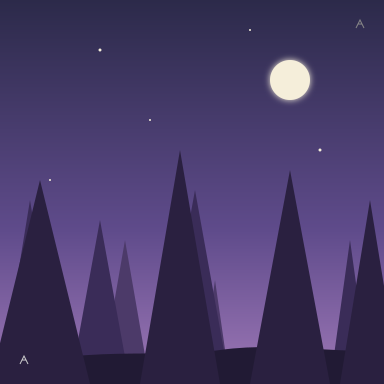


Description: gray wool coat with a faux fur collar
SVG Length: 1701 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg">
<defs>
<linearGradient id="coatGradient" x1="0%" y1="0%" x2="100%" y2="0%">
<stop offset="0%" style="stop-color:#A0A0A0;stop-opacity:1" />
<stop offset="50%" style="stop-color:#B8B8B8;stop-opacity:1" />
<stop offset="100%" style="stop-color:#A0A0A0;stop-opacity:1" />
</linearGradient>
<filter id="furTexture" x="-20%" y="-20%" width="140%" height="140%">
<feTurbulence type="fractalNoise" baseFrequency="0.1 0.2" numOctaves="3" result="turbulence"/>
<feDisplacementMap in="SourceGraphic" in2="turbulence" scale="4" xChannelSelector="R" yChannelSelector="G"/>
</filter>
</defs>
<g>
<path fill="#9E9E9E" d="M112,50 L112,334 L272,334 L272,50 L220,50 L192,80 L164,50 Z"/>
<path fill="url(#coatGradient)" d="M117,55 L117,329 L187,329 L187,85 L164,55 Z"/>
<path fill="url(#coatGradient)" d="M267,55 L267,329 L197,329 L197,85 L220,55

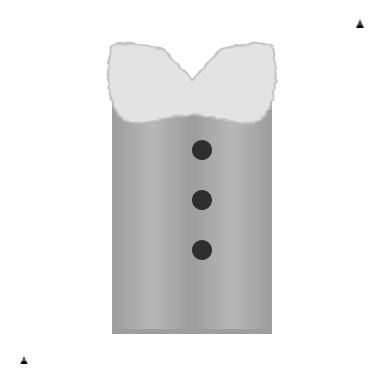


Description: a lighthouse overlooking the ocean
SVG Length: 1721 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg" fill="none">
<defs>
<linearGradient id="skyGradient" x1="0.5" y1="0" x2="0.5" y2="1">
<stop stop-color="#87CEEB"/>
<stop offset="1" stop-color="#B0E0E6"/>
</linearGradient>
<linearGradient id="oceanGradient" x1="0.5" y1="0" x2="0.5" y2="1">
<stop stop-color="#4682B4"/>
<stop offset="1" stop-color="#000080"/>
</linearGradient>
</defs>
<rect width="384" height="384" fill="url(#skyGradient)"/>
<path d="M0 240C128 220, 256 260, 384 240V384H0V240Z" fill="url(#oceanGradient)"/>
<path d="M128 296C192 290, 256 302, 320 296" stroke="#FFFFFF" stroke-opacity="0.5" stroke-width="2" stroke-linecap="round"/>
<path d="M64 320C128 314, 192 326, 256 320" stroke="#FFFFFF" stroke-opacity="0.5" stroke-width="2" stroke-linecap="round"/>
<path d="M160 344C224 338, 288 350, 352 344" stroke="#FFFFFF" stroke-opacity="0.5" stroke-width="2" strok

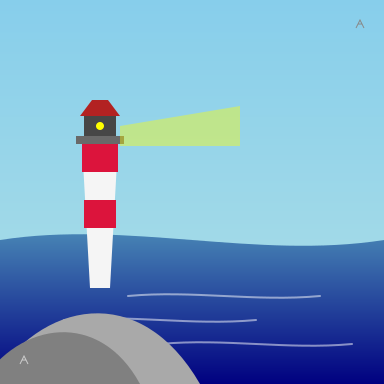


Description: burgundy corduroy pants with patch pockets and silver buttons
SVG Length: 2493 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg" xmlns:xlink="http://www.w3.org/1999/xlink">
<defs>
  <linearGradient id="silverGradient" x1="0%" y1="0%" x2="100%" y2="100%">
    <stop offset="0%" style="stop-color:#E0E0E0;stop-opacity:1" />
    <stop offset="100%" style="stop-color:#A0A0A0;stop-opacity:1" />
  </linearGradient>
  <clipPath id="pantsClip">
    <path d="M128,40 C128,40 132,60 148,64 L236,64 C252,60 256,40 256,40 L256,88 L280,352 L200,352 L200,160 L184,160 L184,352 L104,352 L128,88 Z"/>
    <path d="M232,200 C232,200 220,196 208,204 L208,256 C208,268 220,272 232,272 L268,272 C280,272 292,268 292,256 L292,204 C280,196 268,200 268,200 Z M152,200 C152,200 164,196 176,204 L176,256 C176,268 164,272 152,272 L116,272 C104,272 92,268 92,256 L92,204 C104,196 116,200 116,200 Z"/>
  </clipPath>
  <pattern id="corduroy" patternUnits="user

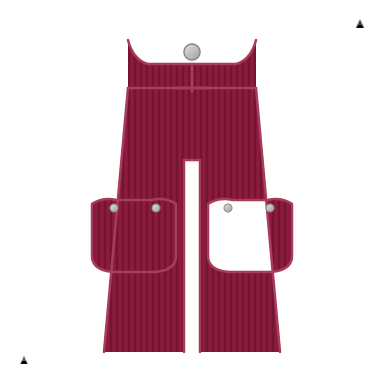


Description: orange corduroy overalls
SVG Length: 2121 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" fill="none" xmlns="http://www.w3.org/2000/svg">
<defs>
<pattern id="corduroy" patternUnits="userSpaceOnUse" width="8" height="8">
<path d="M 0 0 V 8 M 4 0 V 8" stroke="#D97706" stroke-width="1.5"/>
</pattern>
</defs>
<g fill="#F97316" stroke="#9A3412" stroke-width="4" stroke-linecap="round" stroke-linejoin="round">
<path d="M128 352 L128 192 C128 174.327 142.327 160 160 160 H224 C241.673 160 256 174.327 256 192 L256 352"/>
<path d="M128 352 C128 352 144 320 192 320 C240 320 256 352 256 352"/>
<path d="M128 192 C128 192 112 208 112 240 C112 272 128 288 128 288"/>
<path d="M256 192 C256 192 272 208 272 240 C272 272 256 288 256 288"/>
<path d="M140 64 L128 184" />
<path d="M244 64 L256 184" />
<path d="M128 96 L140 64 C148 40 176 32 192 32 C208 32 236 40 244 64 L256 96" />
<path d="M192 256 C178.745 256 168 245.255 168 232 L168 192 C168 178.745 178.745 168 192 168 C2

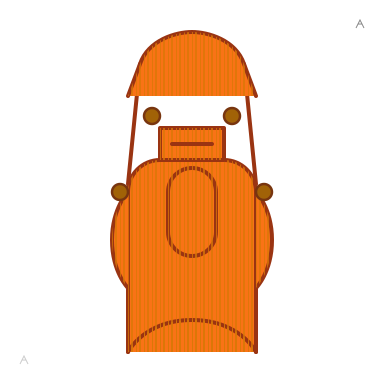


Description: a purple silk scarf with tassel trim
SVG Length: 1713 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg" fill="none">
<defs>
<linearGradient id="silkGradient" x1="0" y1="0" x2="1" y2="1">
<stop offset="0%" stop-color="#A855F7"/>
<stop offset="50%" stop-color="#9333EA"/>
<stop offset="100%" stop-color="#6B21A8"/>
</linearGradient>
</defs>
<path d="M40.23,101.48 C76.53,53.05 158.55,44.73 211.77,91.8 C265,138.87 278.43,212.9 231.36,266.12 C246.33,254.15 289.41,223.37 344,226 C334.33,260.67 312.67,286.33 286,294 C237.6,311.93 151.77,320.18 97.47,268.04 C43.17,215.9 -1.68,141.48 40.23,101.48 Z" fill="url(#silkGradient)"/>
<path d="M97.47,268.04 C104.53,248.68 126.88,230.15 152.12,230.73 C184.58,231.48 206.5,257.07 231.36,266.12 C184.29,297.87 122.9,297.04 97.47,268.04 Z" fill="#6B21A8" fill-opacity="0.5"/>
<g fill="#A855F7">
<rect x="231" y="266" width="6" height="6" rx="3"/>
<path d="M231 272 h1 v15 h-1 z"/>
<path d="M233 27

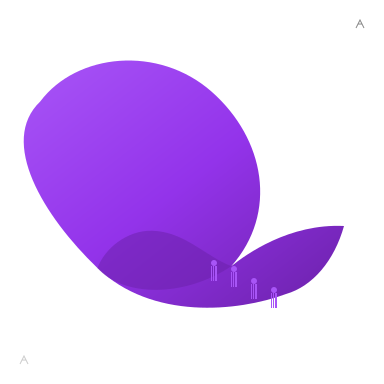


Description: a green lagoon under a cloudy sky
SVG Length: 1161 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg">
<defs>
<linearGradient id="skyGradient" x1="0.5" y1="0" x2="0.5" y2="1">
<stop offset="0%" stop-color="#a0d2eb"/>
<stop offset="100%" stop-color="#d4eaf7"/>
</linearGradient>
<linearGradient id="lagoonGradient" x1="0.5" y1="0" x2="0.5" y2="1">
<stop offset="0%" stop-color="#48b3a5"/>
<stop offset="100%" stop-color="#008080"/>
</linearGradient>
</defs>
<rect x="0" y="0" width="384" height="384" fill="url(#skyGradient)"/>
<path d="M-20 200 H 404 V 384 H -20 Z" fill="url(#lagoonGradient)"/>
<g fill="#FFFFFF" opacity="0.85">
<path d="M 60,150 C 40,150 40,120 70,120 C 80,90 130,90 140,120 C 170,120 170,150 150,150 Z"/>
<path d="M 220,130 C 200,130 200,100 230,100 C 240,70 290,70 300,100 C 330,100 330,130 310,130 Z"/>
<path d="M 150,180 C 130,180 130,150 160,150 C 170,120 220,120 230,150 C 260,150 260,180 240,180 Z"/>
<path d

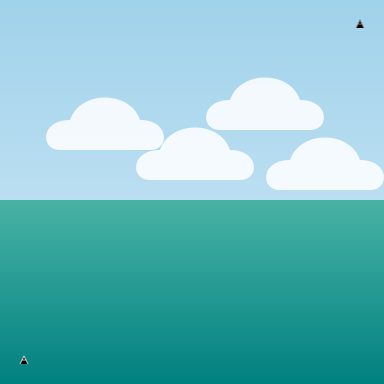


Description: crimson rectangles forming a chaotic grid
SVG Length: 1778 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg" fill="none">
<g fill="#DC143C" stroke="#A40F2C" stroke-width="2">
<rect x="25" y="40" width="70" height="50" transform="rotate(-5 60 65)"/>
<rect x="110" y="35" width="90" height="60" transform="rotate(3 155 65)"/>
<rect x="220" y="20" width="60" height="80" transform="rotate(-8 250 60)"/>
<rect x="300" y="50" width="55" height="45" transform="rotate(10 327.5 72.5)"/>
<rect x="15" y="100" width="85" height="40" transform="rotate(7 57.5 120)"/>
<rect x="95" y="115" width="50" height="70" transform="rotate(-4 120 150)"/>
<rect x="160" y="105" width="75" height="55" transform="rotate(2 197.5 132.5)"/>
<rect x="250" y="120" width="80" height="65" transform="rotate(-6 290 152.5)"/>
<rect x="30" y="170" width="60" height="80" transform="rotate(-10 60 210)"/>
<rect x="105" y="195" width="95" height="50" transform="rotat

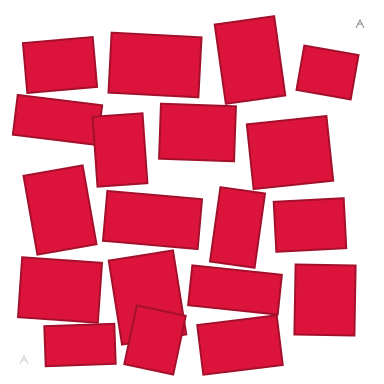


Description: purple pyramids spiraling around a bronze cone
SVG Length: 2088 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg" fill="none">
<defs>
    <linearGradient id="bronzeGradient" x1="50%" y1="0%" x2="50%" y2="100%">
      <stop offset="0%" stop-color="#E6B86C"/>
      <stop offset="50%" stop-color="#CD7F32"/>
      <stop offset="100%" stop-color="#8C5C2C"/>
    </linearGradient>
    <linearGradient id="purpleGradient" x1="50%" y1="0%" x2="50%" y2="100%">
      <stop offset="0%" stop-color="#A978E4"/>
      <stop offset="100%" stop-color="#5D3A99"/>
    </linearGradient>
    <filter id="glow">
      <feGaussianBlur stdDeviation="3.5" result="coloredBlur"/>
      <feMerge>
        <feMergeNode in="coloredBlur"/>
        <feMergeNode in="SourceGraphic"/>
      </feMerge>
    </filter>
</defs>
<rect width="384" height="384" fill="#1C1824"/>
<g filter="url(#glow)">
  <path d="M 92,300 L 192,60 L 292,300 Z" fill="url(#bronzeGradie

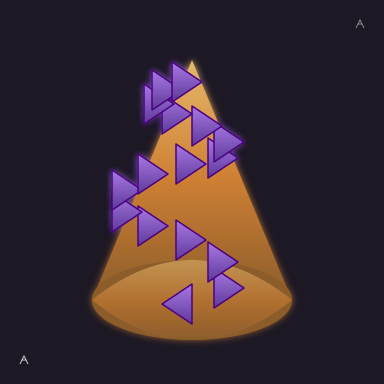


Description: magenta trapezoids layered on a transluscent silver sheet
SVG Length: 1058 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg">
<defs>
<linearGradient id="silverGradient" x1="0%" y1="0%" x2="100%" y2="100%">
<stop offset="0%" style="stop-color:#f0f0f0;stop-opacity:1" />
<stop offset="100%" style="stop-color:#b0b0b0;stop-opacity:1" />
</linearGradient>
</defs>
<rect width="384" height="384" fill="#f9f9f9"/>
<rect x="32" y="32" width="320" height="320" fill="url(#silverGradient)" fill-opacity="0.5" rx="12"/>
<polygon points="60,280 180,100 240,100 120,280" fill="#D90077" opacity="0.85" transform="rotate(-5 192 192)"/>
<polygon points="140,324 260,144 320,144 200,324" fill="#FF0095" opacity="0.9" transform="rotate(0 192 192)"/>
<polygon points="220,90 310,90 340,220 250,220" fill="#E60085" opacity="0.95" transform="rotate(10 192 192)"/>
<polygon points="44,180 144,40 204,40 104,180" fill="#C2006B" opacity="0.8" transform="ro

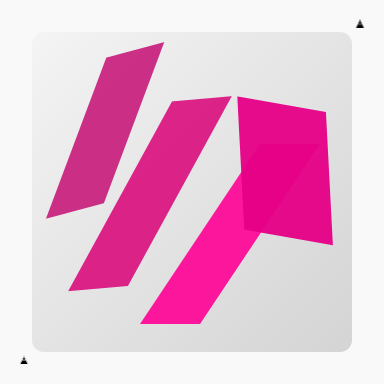


Description: a snowy plain
SVG Length: 2275 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg">
<defs>
<linearGradient id="skyGradient" x1="0%" y1="0%" x2="0%" y2="100%">
<stop offset="0%" style="stop-color:#D4E6F1;stop-opacity:1"/>
<stop offset="100%" style="stop-color:#F4F6F7;stop-opacity:1"/>
</linearGradient>
<filter id="shadow" x="-20%" y="-20%" width="140%" height="140%">
<feGaussianBlur in="SourceAlpha" stdDeviation="3"/>
<feOffset dx="0" dy="2" result="offsetblur"/>
<feComponentTransfer>
<feFuncA type="linear" slope="0.5"/>
</feComponentTransfer>
<feMerge>
<feMergeNode/>
<feMergeNode in="SourceGraphic"/>
</feMerge>
</filter>
</defs>
<rect width="384" height="384" fill="url(#skyGradient)"/>
<g id="snowfall">
<circle cx="50" cy="100" r="1.5" fill="white" opacity="0.8"/>
<circle cx="150" cy="50" r="1" fill="white" opacity="0.9"/>
<circle cx="250" cy="150" r="2" fill="white" opacity="0.7"/>
<circle cx="350" cy="80" r="1.2" fill="

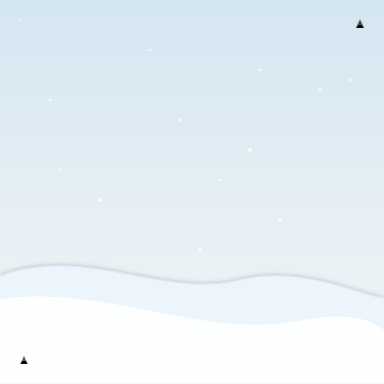


Description: black and white checkered pants
SVG Length: 1030 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg" fill="none">
<defs>
<pattern id="checkerPattern" patternUnits="userSpaceOnUse" width="24" height="24">
<rect width="24" height="24" fill="white"/>
<rect width="12" height="12" fill="black"/>
<rect x="12" y="12" width="12" height="12" fill="black"/>
</pattern>
</defs>
<g stroke="black" stroke-width="8" stroke-linecap="round" stroke-linejoin="round">
<path d="M128 64H256V88C256 88 224 96 192 96C160 96 128 88 128 88V64Z" fill="url(#checkerPattern)"/>
<path d="M192 96V144M168 144H216" stroke-width="6"/>
<path d="M128 88C112 112 96 184 96 240C96 280 112 320 112 320H176C176 320 160 280 160 240C160 200 176 120 192 96" fill="url(#checkerPattern)"/>
<path d="M256 88C272 112 288 184 288 240C288 280 272 320 272 320H208C208 320 224 280 224 240C224 200 208 120 192 96" fill="url(#checkerPattern)"/>
</g>
<path d="M20 364 L24 356 L28 364 

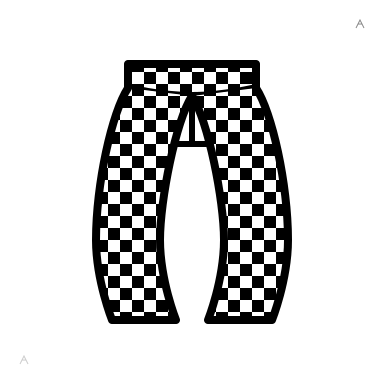


Description: a starlit night over snow-covered peaks
SVG Length: 2335 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg" fill="none">
<defs>
<linearGradient id="skyGradient" x1="0.5" y1="0" x2="0.5" y2="1">
<stop offset="0%" stop-color="#0a0f2c"/>
<stop offset="100%" stop-color="#141852"/>
</linearGradient>
</defs>
<rect width="384" height="384" fill="url(#skyGradient)"/>
<circle cx="50" cy="60" r="1.5" fill="#FFFFFF" opacity="0.9"/>
<circle cx="120" cy="40" r="1" fill="#FFFFFF" opacity="0.8"/>
<circle cx="200" cy="80" r="2" fill="#FFFFFF" opacity="1"/>
<circle cx="280" cy="50" r="1.2" fill="#FFFFFF" opacity="0.9"/>
<circle cx="340" cy="90" r="1" fill="#FFFFFF" opacity="0.7"/>
<circle cx="90" cy="110" r="1.5" fill="#FFFFFF" opacity="0.85"/>
<circle cx="150" cy="150" r="1" fill="#FFFFFF" opacity="0.9"/>
<circle cx="250" cy="130" r="1.8" fill="#FFFFFF" opacity="0.95"/>
<circle cx="310" cy="160" r="1" fill="#FFFFFF" opacity="0.8"/>
<cir

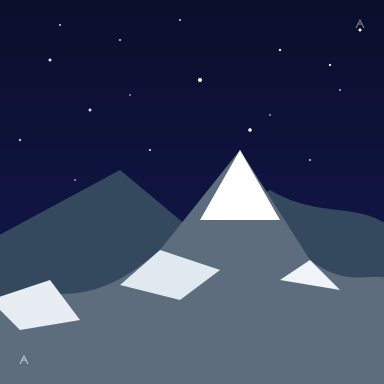


Description: khaki triangles and azure crescents
SVG Length: 852 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg">
<g fill="#C3B091" stroke="none">
<polygon points="165,40 235,110 140,125"/>
<polygon points="40,240 140,260 70,340"/>
<polygon points="310,180 350,270 250,260"/>
<polygon points="50,80 120,40 130,130"/>
<polygon points="260,300 340,350 360,280"/>
</g>
<g fill="#007FFF" stroke="none">
<path d="M 80,50 A 70 70 0 0 1 150,160 A 55 55 0 0 0 80,50 Z"/>
<path d="M 280,240 A 50 50 0 0 1 340,330 A 40 40 0 0 0 280,240 Z"/>
<path d="M 200,150 A 60 60 0 0 1 290,240 A 45 45 0 0 0 200,150 Z"/>
<path d="M 60,160 A 45 45 0 0 1 130,220 A 30 30 0 0 0 60,160 Z"/>
<path d="M 270,60 A 35 35 0 0 1 330,110 A 25 25 0 0 0 270,60 Z"/>
</g>
<path d="M20 364 L24 356 L28 364 M22 360 L26 360" stroke="#CCCCCC"/><path d="M364 28 L360 20 L356 28 M362 24 L358 24" stroke="#888888"/></svg>


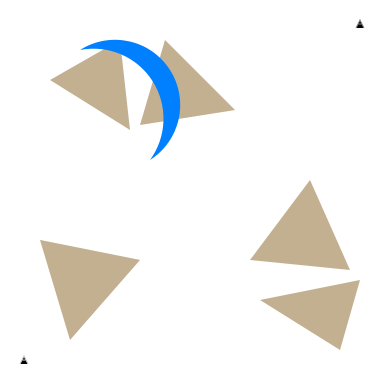


Description: a maroon dodecahedron interwoven with teal threads
SVG Length: 2272 characters
SVG: <svg width="384" height="384" viewBox="0 0 384 384" xmlns="http://www.w3.org/2000/svg" fill="none" stroke-linejoin="round" stroke-linecap="round">
<defs>
  <path id="threadPath1" d="M 192,42 Q 130,120 192,192 Q 254,264 192,342"/>
  <path id="threadPath2" d="M 62,113 Q 120,180 192,192 Q 264,204 322,271"/>
  <path id="threadPath3" d="M 322,113 Q 264,180 192,192 Q 120,204 62,271"/>
  <path id="threadPath4" d="M 104,324 Q 160,250 192,192 Q 224,134 280,58"/>
  <path id="threadPath5" d="M 280,324 Q 224,250 192,192 Q 160,134 104,58"/>
</defs>
<g id="dodecahedron" stroke="#800000" stroke-width="8">
  <path d="M 192,42 L 280,113 L 230,210 L 104,210 L 62,113 Z"/>
  <path d="M 192,42 L 104,113 L 154,210"/>
  <path d="M 280,113 L 322,184 L 230,210"/>
  <path d="M 62,113 L 104,210"/>
  <path d="M 62,113 L 16,184 L 104,210"/>
  <path d="M 154,210 L 104,302 L 16,184" fill="#800000" fill-opacity="0.1"/>
 

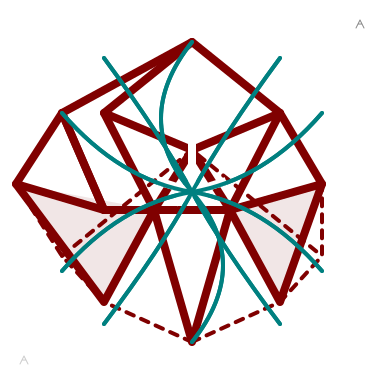

In [6]:
from IPython.display import SVG, display

# Display first few results
for idx, row in df.iterrows():
    print(f"\n{'='*80}")
    print(f"Description: {row.description}")
    print(f"SVG Length: {len(row.svg)} characters")
    print(f'SVG: {row.svg}')
    display(SVG(row.svg))



## Summary



In [7]:
print("Generation Summary:")
print(f"Total samples: {len(df)}")
print(f"Average SVG length: {df['svg'].str.len().mean():.0f} characters")
print(f"Max SVG length: {df['svg'].str.len().max()} characters")
print(f"Min SVG length: {df['svg'].str.len().min()} characters")
print(f"\nResults saved to: res_gemini_pro.csv")



Generation Summary:
Total samples: 15
Average SVG length: 1786 characters
Max SVG length: 2493 characters
Min SVG length: 852 characters

Results saved to: res_gemini_pro.csv
